# MaskCLIP vs Talk2DINO

Side-by-side comparison of the two patch-level feature extractors on a birds scene frame. MaskCLIP (CLIP ViT-L/14) extracts dense patch features with a text encoder, while Talk2DINO combines a DINOv3 backbone with a CLIP projection for stronger structural grounding. This notebook visualizes PCA feature decomposition and query-similarity heatmaps for each extractor across several text queries.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline

from collab_splats.preproc import FrameStore
from collab_splats.semantics.features import (
    BaseFeatureExtractor,
    MaskCLIPExtractor,
    Talk2DinoExtractor,
)
from collab_splats.utils.visualization import pca_to_rgb, compute_heatmap, compute_masked_image

print("Registered extractors:", list(BaseFeatureExtractor._registry.keys()))

## §1 — Configuration

Set dataset path, text queries, and load the reference frame used for all comparisons below.

In [ ]:
%run ../tutorial_config.py

# ── Configuration ─────────────────────────────────────────────────────────────
QUERIES = ["tree", "bark", "sky"]
NEGATIVES = []

# First keyframe from the canonical frames.zarr (nb 01)
frame = FrameStore.open(FRAMES_ZARR).image(0)
print(f"Loaded first keyframe  shape={frame.shape}")

plt.figure(figsize=(6, 4))
plt.imshow(frame)
plt.axis("off")
plt.title("Reference frame")
plt.tight_layout()
plt.show()

## §2 — MaskCLIP features

MaskCLIP uses a CLIP ViT-L/14@336px backbone to extract dense patch features. The PCA projection shows spatial feature variation; the heatmap shows cosine similarity to the text queries.

In [4]:
# Load MaskCLIP extractor
extractor_mc = MaskCLIPExtractor()
print("MaskCLIP loaded. Patch size:", extractor_mc.patch_size)

MaskCLIP loaded. Patch size: 14


In [5]:
# Extract MaskCLIP patch features for the reference frame
features_mc = extractor_mc.forward([frame])  # list of (C, pH, pW)
print("MaskCLIP feature shape:", features_mc[0].shape)

MaskCLIP feature shape: torch.Size([768, 73, 41])


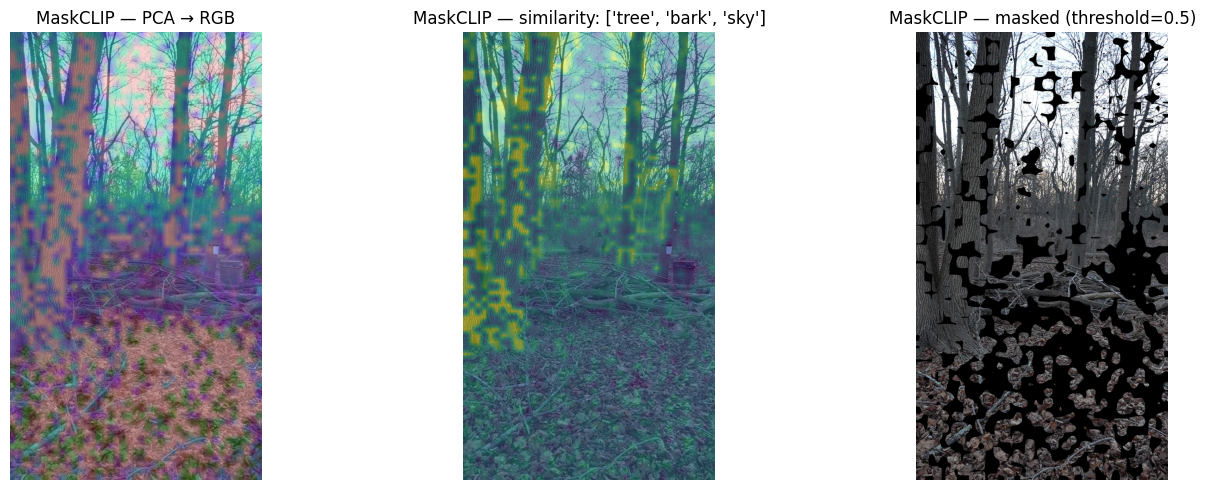

In [6]:
# Score queries and visualize PCA + heatmap + masked image
sim_mc = extractor_mc.score_queries(features_mc[0], positive=QUERIES, negative=NEGATIVES or None)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(pca_to_rgb(features_mc[0], frame))
axes[0].set_title("MaskCLIP — PCA → RGB")
axes[1].imshow(compute_heatmap(frame, sim_mc))
axes[1].set_title(f"MaskCLIP — similarity: {QUERIES}")
axes[2].imshow(compute_masked_image(frame, sim_mc))
axes[2].set_title("MaskCLIP — masked (threshold=0.5)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## §3 — Talk2DINO features

Talk2DINO uses a DINOv3 ViT-B backbone with a CLIP projection head. It center-crops internally for a fixed input resolution. Comparing the PCA and heatmaps against MaskCLIP reveals differences in spatial resolution, boundary sharpness, and semantic specificity.

In [7]:
# Load Talk2DINO extractor
extractor_t2d = Talk2DinoExtractor(model_name="lorebianchi98/Talk2DINOv3-ViTB")
print("Talk2DINO loaded. Patch size:", extractor_t2d.patch_size)

Some weights of the model checkpoint at lorebianchi98/Talk2DINOv3-ViTB were not used when initializing Talk2DINO: ['pamr.aff_m.kernel', 'pamr.aff_std.kernel', 'pamr.aff_x.kernel']
- This IS expected if you are initializing Talk2DINO from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Talk2DINO from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Talk2DINO loaded. Patch size: 16


In [8]:
# Extract Talk2DINO features — forward() center-crops internally
features_t2d = extractor_t2d.forward([frame])
print("Talk2DINO feature shape:", features_t2d[0].shape)

Talk2DINO feature shape: torch.Size([768, 32, 18])


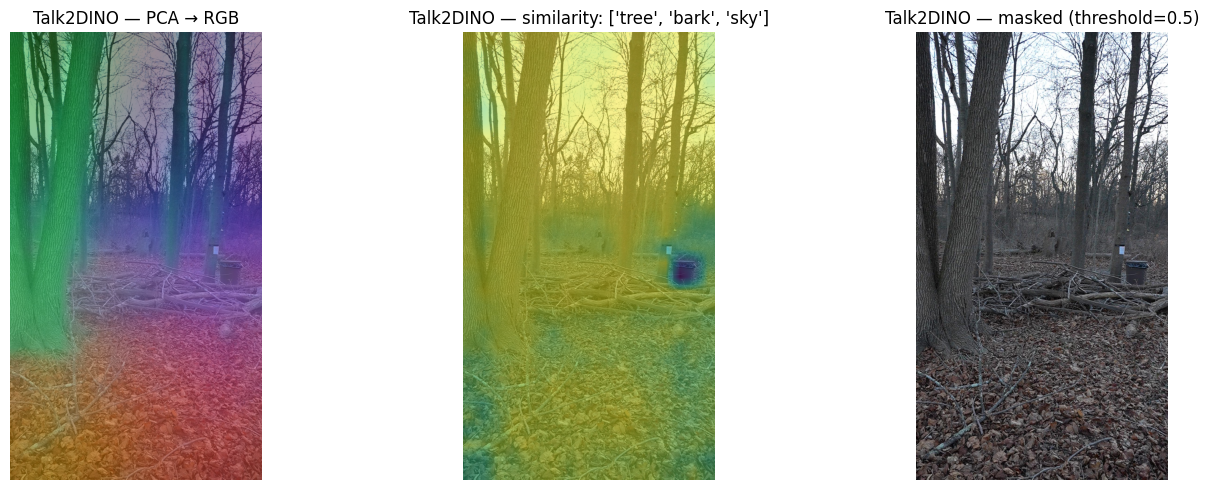

In [9]:
# Score queries and visualize PCA + heatmap + masked image
sim_t2d = extractor_t2d.score_queries(features_t2d[0], positive=QUERIES, negative=NEGATIVES or None)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(pca_to_rgb(features_t2d[0], frame))
axes[0].set_title("Talk2DINO — PCA → RGB")
axes[1].imshow(compute_heatmap(frame, sim_t2d))
axes[1].set_title(f"Talk2DINO — similarity: {QUERIES}")
axes[2].imshow(compute_masked_image(frame, sim_t2d))
axes[2].set_title("Talk2DINO — masked (threshold=0.5)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## §4 — Side-by-side query comparison

Run both extractors on each query in `QUERIES` and display similarity heatmaps in a grid: rows are queries, columns are extractors. This makes it easy to spot where MaskCLIP and Talk2DINO agree or diverge.

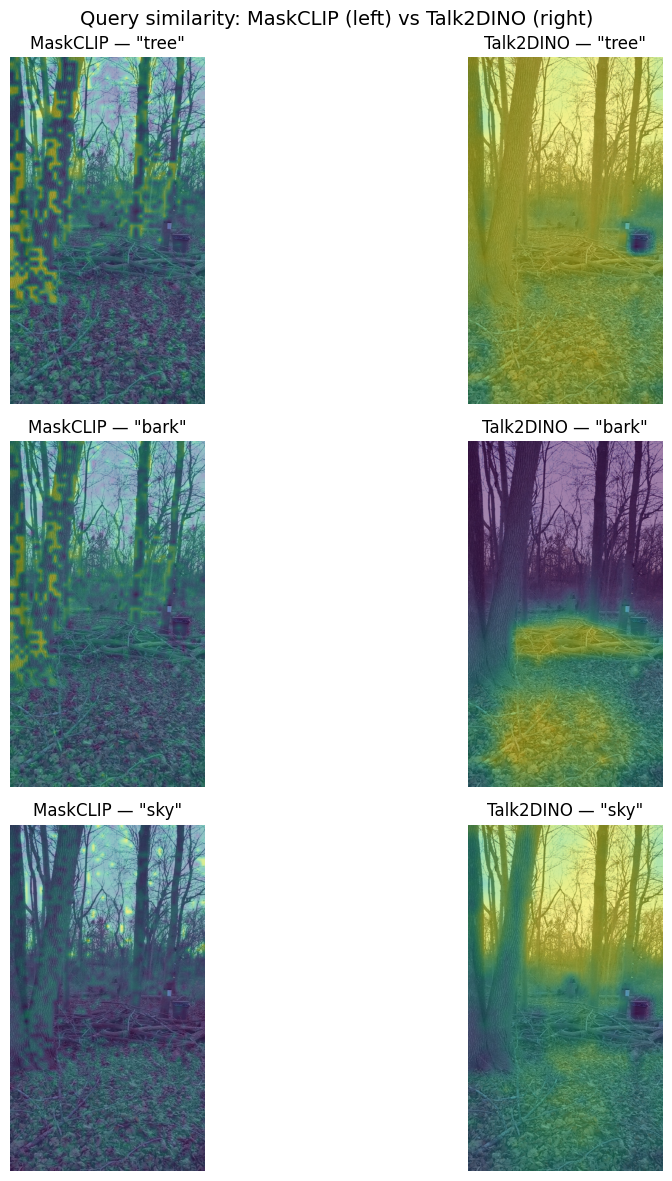

In [10]:
# Compare MaskCLIP vs Talk2DINO heatmaps for each query in QUERIES
fig, axes = plt.subplots(len(QUERIES), 2, figsize=(12, 4 * len(QUERIES)))

for row, query in enumerate(QUERIES):
    # Score single query against default contrastive background
    sim_mc_q = extractor_mc.score_queries(features_mc[0], positive=[query])
    sim_t2d_q = extractor_t2d.score_queries(features_t2d[0], positive=[query])

    axes[row, 0].imshow(compute_heatmap(frame, sim_mc_q))
    axes[row, 0].set_title(f'MaskCLIP — "{query}"')
    axes[row, 0].axis("off")

    axes[row, 1].imshow(compute_heatmap(frame, sim_t2d_q))
    axes[row, 1].set_title(f'Talk2DINO — "{query}"')
    axes[row, 1].axis("off")

plt.suptitle("Query similarity: MaskCLIP (left) vs Talk2DINO (right)", fontsize=14)
plt.tight_layout()
plt.show()

## §5 — Summary

| | MaskCLIP | Talk2DINO |
|---|---|---|
| Backbone | CLIP ViT-L/14@336px | DINOv3 ViT-B + CLIP projection |
| Feature dim | 1024 | 512 |
| Input handling | Longest-edge resize | Center-crop to square |
| Text encoder | CLIP | Talk2DINO (DINO-aligned) |
| Segmentation | Optional (SAM) | No |

**Key differences to look for:**
- MaskCLIP tends to produce higher-resolution patch grids (ViT-L larger stride handles fine texture well)
- Talk2DINO's DINOv3 backbone gives stronger structural/semantic grounding — watch for cleaner semantic boundaries
- Both use contrastive softmax scoring via `score_queries`; adjust `temperature` for sharper/softer maps